# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [24]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
!pip install -q scikit-learn pandas joblib
!pip install xgboost
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline

In [25]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [26]:
# Check for missing values
rows_before = len(df)
df_clean = df.dropna().reset_index(drop=True)
rows_after = len(df_clean)
print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning : {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")


# Display summary statistics
display(df_clean.describe())
counts = df_clean['sensor_id'].value_counts()
print(counts)

Rows before cleaning: 701548
Rows after cleaning : 701548
Rows removed: 0


,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


sensor_id
1962    18216
2264    18208
1954    18201
1764    18198
1846    18184
2262    18184
2607    18156
3092    18152
3738    18132
3836    18108
3432    18084
2294    18079
2038    18053
2224    18025
2234    18008
2036    17982
3474    17941
3472    17931
2228    17893
3102    17845
2266    17708
1850    17703
2230    17617
2323    17370
3096    17201
3512    17070
3500    16818
2232    16145
3620    15696
1952    15383
3428    15258
3982    14695
3438    14333
3436    13028
3296    12574
2216    11661
2292    11003
3642    10198
2040     9762
4358     7547
3558     6998
3968     6745
4469     4346
4471     4322
4477     4310
4479     4308
4473     4267
4467     3965
4475     3957
4558     3009
4608     2022
3328     1238
3326      835
4625      579
3832      214
4661       83
Name: count, dtype: int64


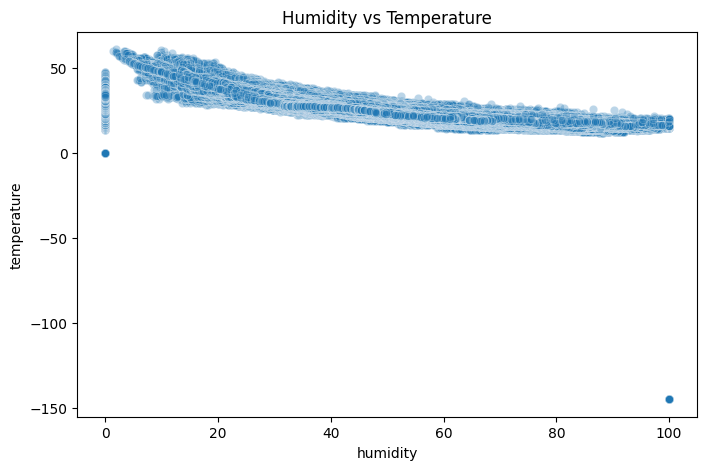

In [27]:
# Scatter plot to observe relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x='humidity', y='temperature', data=df, alpha=0.3)
plt.title('Humidity vs Temperature')
plt.show()

In [28]:
df_clean = df_clean[
    (df_clean['temperature'] > -30) &
    (df_clean['temperature'] < 60)
]

df_clean["humidity_pressure"] = df_clean["humidity"] * df_clean["pressure"]
df_clean["humidity_sq"] = df_clean["humidity"] ** 2
df_clean["pressure_sq"] = df_clean["pressure"] ** 2

## Data Features and Target

In [29]:
# Define features(X) and target(Y)
X = df_clean.drop(['temperature','sensor_id'], axis=1)
y = df_clean['temperature']


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')


Train size: 558242, Test size: 139561


## Model Training

In [30]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Evaluation


In [31]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 1.9604525704070825
R2: 0.9080519543302504


## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.


In [32]:
# Save the trained model
joblib.dump(model, "temperature_model.pkl")
print("Model saved to temperature_model.pkl")

Model saved to temperature_model.pkl
